In [2]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# This relates to plotting datetime values with matplotlib:
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [4]:
path_ = '/Users/arunkumarsadanandan/Desktop/DL-LSTM Workshop/Classical Models/Time-Series-Analysis-and-Forecasting-with-Python-master/data/Alcohol_Sales.csv'

In [5]:
df = pd.read_csv(path_,index_col=0,parse_dates=True)
len(df)

325

In [6]:
df.head()

,S4248SM144NCEN
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221


In [7]:
df.dropna(inplace=True)
len(df)

325

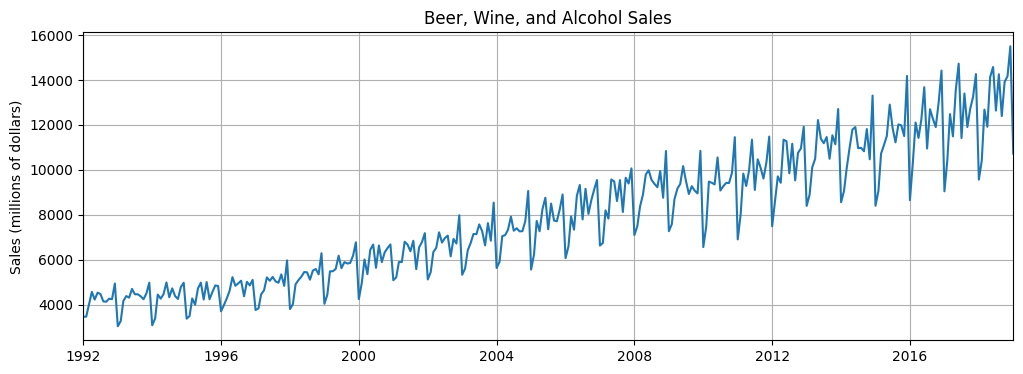

In [8]:
plt.figure(figsize=(12,4))
plt.title('Beer, Wine, and Alcohol Sales')
plt.ylabel('Sales (millions of dollars)')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['S4248SM144NCEN'])
plt.show()

In [9]:
# Extract values from the source .csv file
y = df['S4248SM144NCEN'].values.astype(float)

# Define a test size
test_size = 12

# Create train and test sets
train_set = y[:-test_size]
test_set = y[-test_size:]

In [11]:
print(f"shape of train_set : {train_set.shape}")
print(f"shape of test_set : {test_set.shape}")

shape of train_set : (313,)
shape of test_set : (12,)


In [12]:
from sklearn.preprocessing import MinMaxScaler

# Instantiate a scaler with a feature range from -1 to 1
scaler = MinMaxScaler(feature_range=(-1, 1))

In [13]:
train_norm = scaler.fit_transform(train_set.reshape(-1, 1))

In [14]:
train_norm = torch.FloatTensor(train_norm).view(-1)

In [16]:
# Convert train_norm from an array to a tensor
train_norm = torch.FloatTensor(train_norm).view(-1)

# Define a window size
window_size = 12

# Define function to create seq/label tuples
def input_data(seq, ws):  # ws is the window size
    out = []
    L = len(seq)
    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window,label))
    return out

# Apply the input_data function to train_norm
train_data = input_data(train_norm,window_size)
len(train_data)  # this should equal 325-12-12

301

In [17]:
train_data

[(tensor([-0.9268, -0.9270, -0.8340, -0.7379, -0.7966, -0.7439, -0.7547, -0.8109,
          -0.8128, -0.7901, -0.7933, -0.6743]),
  tensor([-1.])),
 (tensor([-0.9270, -0.8340, -0.7379, -0.7966, -0.7439, -0.7547, -0.8109, -0.8128,
          -0.7901, -0.7933, -0.6743, -1.0000]),
  tensor([-0.9607])),
 (tensor([-0.8340, -0.7379, -0.7966, -0.7439, -0.7547, -0.8109, -0.8128, -0.7901,
          -0.7933, -0.6743, -1.0000, -0.9607]),
  tensor([-0.8070])),
 (tensor([-0.7379, -0.7966, -0.7439, -0.7547, -0.8109, -0.8128, -0.7901, -0.7933,
          -0.6743, -1.0000, -0.9607, -0.8070]),
  tensor([-0.7699])),
 (tensor([-0.7966, -0.7439, -0.7547, -0.8109, -0.8128, -0.7901, -0.7933, -0.6743,
          -1.0000, -0.9607, -0.8070, -0.7699]),
  tensor([-0.7819])),
 (tensor([-0.7439, -0.7547, -0.8109, -0.8128, -0.7901, -0.7933, -0.6743, -1.0000,
          -0.9607, -0.8070, -0.7699, -0.7819]),
  tensor([-0.7154])),
 (tensor([-0.7547, -0.8109, -0.8128, -0.7901, -0.7933, -0.6743, -1.0000, -0.9607,
          

In [18]:
class SalesPredictor(nn.Module):

    def __init__(self, input_size=1, hidden_size=100, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size)
        self.linear = nn.Linear(hidden_size, output_size)
        self.hidden = (torch.zeros(1, 1, self.hidden_size),
                       torch.zeros(1, 1, self.hidden_size))
        

    def forward(self, seq):
        out, self.hidden = self.lstm(seq.view(len(seq), 1, -1), self.hidden)
        pred = self.linear(out.view(len(seq), -1))
        return pred[-1]

In [19]:
predictorModel = SalesPredictor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(predictorModel.parameters(), lr=0.001)

In [20]:
epochs = 100

import time
start_time = time.time()

for epoch in range(epochs):
    
    # extract the sequence & label from the training data
    for seq, y_train in train_data:
        
        # reset the parameters and hidden states
        optimizer.zero_grad()
        predictorModel.hidden = (torch.zeros(1,1,predictorModel.hidden_size),
                                torch.zeros(1,1,predictorModel.hidden_size))
        
        y_pred = predictorModel(seq)
        
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        
    # print training result
    print(f'Epoch: {epoch+1:2} Loss: {loss.item():10.8f}')
    
print(f'\nDuration: {time.time() - start_time:.0f} seconds')

Epoch:  1 Loss: 0.33718857
Epoch:  2 Loss: 0.41437709
Epoch:  3 Loss: 0.36988479
Epoch:  4 Loss: 0.36527368
Epoch:  5 Loss: 0.31871399
Epoch:  6 Loss: 0.32604104
Epoch:  7 Loss: 0.32768056
Epoch:  8 Loss: 0.32544470
Epoch:  9 Loss: 0.30575550
Epoch: 10 Loss: 0.29778019
Epoch: 11 Loss: 0.29458657
Epoch: 12 Loss: 0.29849058
Epoch: 13 Loss: 0.28371444
Epoch: 14 Loss: 0.28566775
Epoch: 15 Loss: 0.27555588
Epoch: 16 Loss: 0.27448061
Epoch: 17 Loss: 0.27453989
Epoch: 18 Loss: 0.26861110
Epoch: 19 Loss: 0.26475382
Epoch: 20 Loss: 0.26684317
Epoch: 21 Loss: 0.26230475
Epoch: 22 Loss: 0.25617927
Epoch: 23 Loss: 0.24630879
Epoch: 24 Loss: 0.23892994
Epoch: 25 Loss: 0.23215576
Epoch: 26 Loss: 0.24006990
Epoch: 27 Loss: 0.10877656
Epoch: 28 Loss: 0.13131371
Epoch: 29 Loss: 0.03392176
Epoch: 30 Loss: 0.00304013
Epoch: 31 Loss: 0.01074376
Epoch: 32 Loss: 0.03242057
Epoch: 33 Loss: 0.04398409
Epoch: 34 Loss: 0.03736463
Epoch: 35 Loss: 0.02113743
Epoch: 36 Loss: 0.00989892
Epoch: 37 Loss: 0.00090988
E

In [21]:
future = 12

# Add the last window of training values to the list of predictions
preds = train_norm[-window_size:].tolist()

# Set the model to evaluation mode
predictorModel.eval()

for i in range(future):
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        predictorModel.hidden = (torch.zeros(1,1,predictorModel.hidden_size),
                        torch.zeros(1,1,predictorModel.hidden_size))
        preds.append(predictorModel(seq).item())

In [24]:
true_prediction = scaler.inverse_transform(np.array(preds[window_size:]).reshape(1, -1))
true_prediction = true_prediction.squeeze()
x = np.arange('2018-02-01', '2019-02-01', dtype='datetime64[M]').astype('datetime64[D]')

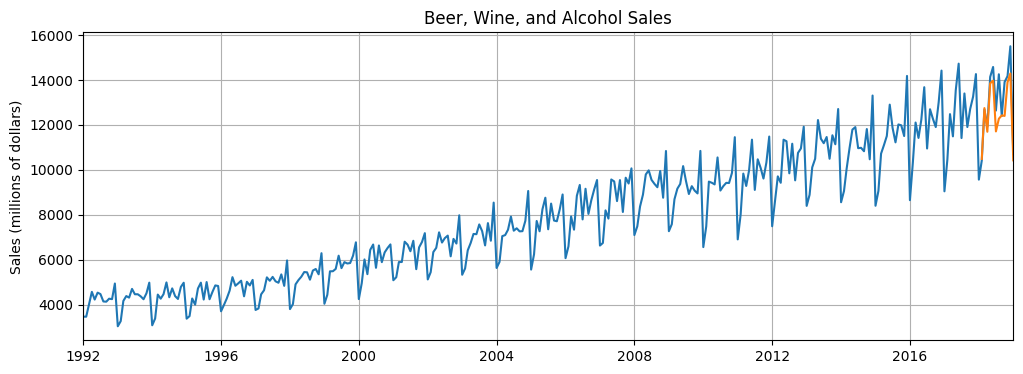

In [25]:
plt.figure(figsize=(12,4))
plt.title('Beer, Wine, and Alcohol Sales')
plt.ylabel('Sales (millions of dollars)')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['S4248SM144NCEN'])
plt.plot(x,true_prediction)
plt.show()

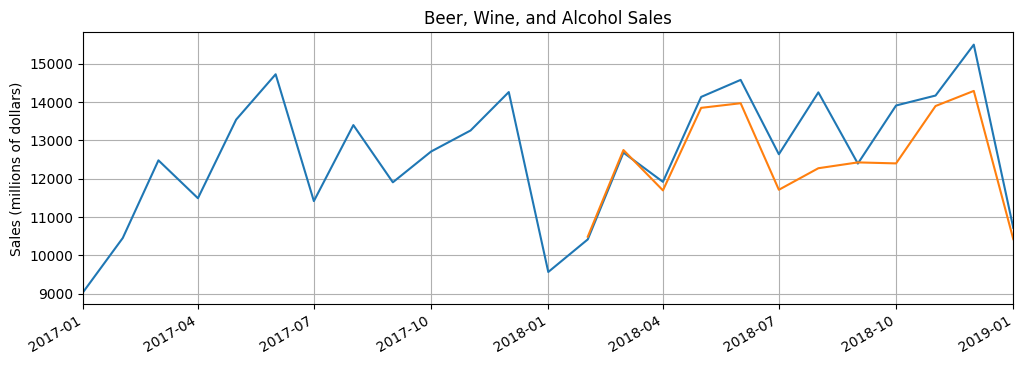

In [26]:
# Plot the end of the graph
fig = plt.figure(figsize=(12,4))
plt.title('Beer, Wine, and Alcohol Sales')
plt.ylabel('Sales (millions of dollars)')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
fig.autofmt_xdate()

# Select the end of the graph with slice notation:
plt.plot(df['S4248SM144NCEN']['2017-01-01':])
plt.plot(x,true_prediction)
plt.show()